# Energy Consumption Forecasting with LSTM
### Domain: Time Series | Framework: PyTorch

---

## 🌍 Problem Description

Energy providers need to forecast electricity demand 24–48 hours ahead to optimize grid load, avoid blackouts, and reduce energy waste. This project builds a **multi-step time series forecaster** that predicts the next 24 hours of energy consumption given the past 7 days of readings.

We implement a **Seq2Seq LSTM** (encoder-decoder architecture) — a staple for multi-step forecasting — and enrich the model with **temporal features** (hour of day, day of week, month) to capture cyclical patterns.

**Real-world challenges we tackle:**
- 📅 **Seasonality** at multiple timescales (daily, weekly, annual)
- 🏗️ **Multi-step forecasting** (predict 24 steps, not just 1)
- 📉 **Distribution shift** between training and test periods
- 🔄 **Proper time-series splitting** — never shuffle time series data!

---

## 📦 Dataset

**Hourly Energy Consumption (PJM)**
- Source: [Kaggle - Hourly Energy Consumption](https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption)
- Hourly electricity consumption (MW) across multiple US regions
- ~10 years of data (2002-2018)
- We use the AEP (American Electric Power) region

---

## 🚀 How to Run This Project

```bash
# 1. Install dependencies
pip install torch pandas numpy matplotlib scikit-learn seaborn tqdm

# 2. Download data
kaggle datasets download -d robikscube/hourly-energy-consumption
unzip hourly-energy-consumption.zip -d ./data/

# 3. Run the notebook
jupyter notebook project3_energy_forecasting_lstm.ipynb
```



In [20]:
!pip install torch pandas numpy matplotlib scikit-learn seaborn tqdm

In [21]:

# IMPORTS


import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


## 📊 Step 1: Data Loading & Exploration

Time series analysis starts with understanding the **temporal structure** of the data: trends, seasonality, and anomalies.

In [22]:

# LOAD DATA


DATA_PATH = './data/AEP_hourly.csv'

df = pd.read_csv(DATA_PATH)
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime').reset_index(drop=True)
df = df.rename(columns={'AEP_MW': 'MW'})

print(f'Date range: {df["Datetime"].min()} → {df["Datetime"].max()}')
print(f'Total hourly readings: {len(df):,}')
print(f'Missing values: {df["MW"].isna().sum()}')
print(f'\nEnergy stats (MW):')
print(df['MW'].describe())

Date range: 2004-10-01 01:00:00 → 2018-08-03 00:00:00
Total hourly readings: 121,273
Missing values: 0

Energy stats (MW):
count    121273.000000
mean      15499.513717
std        2591.399065
min        9581.000000
25%       13630.000000
50%       15310.000000
75%       17200.000000
max       25695.000000
Name: MW, dtype: float64


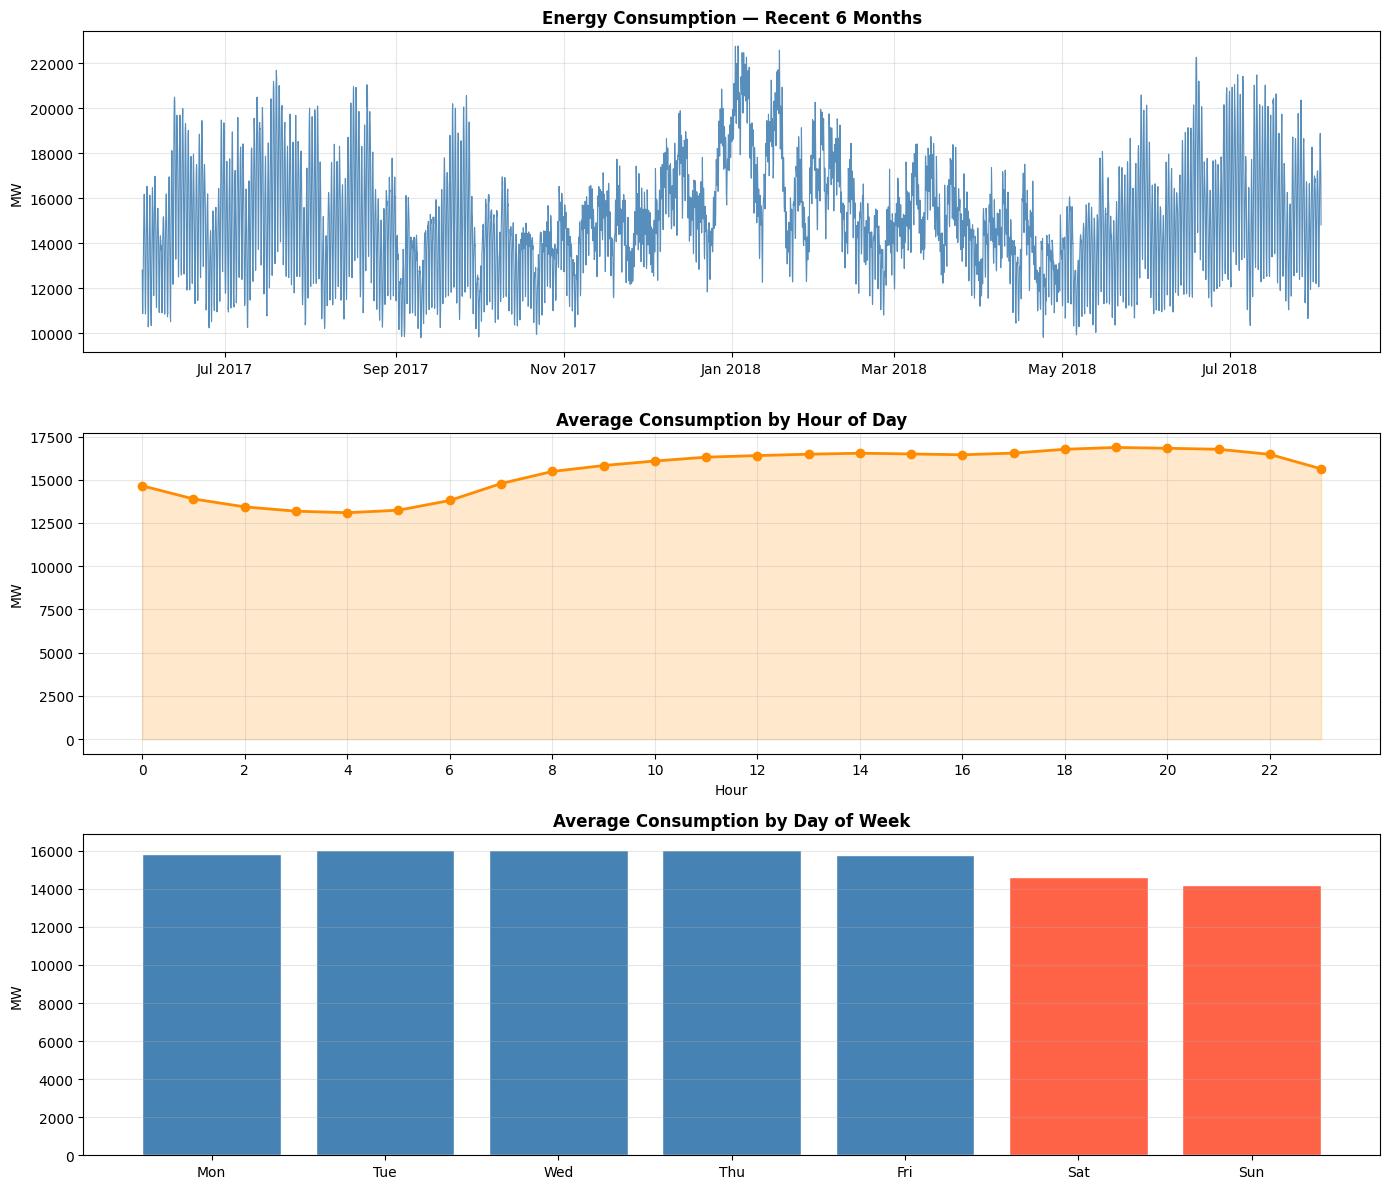


Key observation: clear daily cycle (peak ~18:00, trough ~4:00) and weekend drop!


In [23]:

# VISUALIZE TEMPORAL PATTERNS
# These plots reveal the daily & weekly cycles
# that our model needs to learn


fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Full time series — zoom into recent 6 months
recent = df[df['Datetime'] >= '2017-06-01']
axes[0].plot(recent['Datetime'], recent['MW'], color='steelblue', linewidth=0.8, alpha=0.9)
axes[0].set_title('Energy Consumption — Recent 6 Months', fontsize=12, fontweight='bold')
axes[0].set_ylabel('MW')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].grid(True, alpha=0.3)

# Average consumption by hour of day
df['hour'] = df['Datetime'].dt.hour
hourly_avg = df.groupby('hour')['MW'].mean()
axes[1].plot(hourly_avg.index, hourly_avg.values, 'o-', color='darkorange', linewidth=2)
axes[1].fill_between(hourly_avg.index, hourly_avg.values, alpha=0.2, color='darkorange')
axes[1].set_title('Average Consumption by Hour of Day', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('MW')
axes[1].set_xticks(range(0, 24, 2))
axes[1].grid(True, alpha=0.3)

# Average consumption by day of week
df['dayofweek'] = df['Datetime'].dt.dayofweek
daily_avg = df.groupby('dayofweek')['MW'].mean()
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
colors = ['steelblue'] * 5 + ['tomato'] * 2
axes[2].bar(day_names, daily_avg.values, color=colors, edgecolor='white')
axes[2].set_title('Average Consumption by Day of Week', fontsize=12, fontweight='bold')
axes[2].set_ylabel('MW')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('temporal_patterns.png', dpi=150)
plt.show()
print('\nKey observation: clear daily cycle (peak ~18:00, trough ~4:00) and weekend drop!')

## 🔧 Step 2: Feature Engineering & Preprocessing

LSTMs can theoretically learn temporal patterns, but **giving them explicit time features** (hour, day, month encoded cyclically) accelerates learning and improves accuracy dramatically. 

We use **cyclical encoding** for periodic features: `sin(2π * hour/24)` and `cos(2π * hour/24)` — this way, hour 23 and hour 0 are close to each other, which a plain integer would NOT capture.

In [24]:

# FEATURE ENGINEERING
# Cyclical encoding for periodic features


def add_time_features(df):
    """Add cyclical and binary time features to the dataframe."""
    dt = df['Datetime']

    # Cyclical encoding — prevents artificial discontinuity at boundary
    df['hour_sin']  = np.sin(2 * np.pi * dt.dt.hour   / 24)
    df['hour_cos']  = np.cos(2 * np.pi * dt.dt.hour   / 24)
    df['dow_sin']   = np.sin(2 * np.pi * dt.dt.dayofweek / 7)
    df['dow_cos']   = np.cos(2 * np.pi * dt.dt.dayofweek / 7)
    df['month_sin'] = np.sin(2 * np.pi * dt.dt.month  / 12)
    df['month_cos'] = np.cos(2 * np.pi * dt.dt.month  / 12)

    # Binary indicators
    df['is_weekend'] = (dt.dt.dayofweek >= 5).astype(float)

    return df

df = add_time_features(df)

FEATURE_COLS = ['MW', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
                'month_sin', 'month_cos', 'is_weekend']

print(f'Feature columns: {FEATURE_COLS}')
print(f'Total features : {len(FEATURE_COLS)} (1 target + {len(FEATURE_COLS)-1} temporal)')

Feature columns: ['MW', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_weekend']
Total features : 8 (1 target + 7 temporal)


In [25]:

# TRAIN / VAL / TEST SPLIT
# CRITICAL: NEVER shuffle time series data!
# Always use chronological splits.


n = len(df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_df = df.iloc[:train_end]
val_df   = df.iloc[train_end:val_end]
test_df  = df.iloc[val_end:]

print(f'Train: {len(train_df):,} ({train_df["Datetime"].min().date()} → {train_df["Datetime"].max().date()})')
print(f'Val  : {len(val_df):,} ({val_df["Datetime"].min().date()} → {val_df["Datetime"].max().date()})')
print(f'Test : {len(test_df):,} ({test_df["Datetime"].min().date()} → {test_df["Datetime"].max().date()})')


# NORMALIZATION
# Fit scaler on TRAINING set only — do NOT
# include val/test in fit() to avoid data leakage


scaler = StandardScaler()

train_scaled = scaler.fit_transform(train_df[FEATURE_COLS])
val_scaled   = scaler.transform(val_df[FEATURE_COLS])
test_scaled  = scaler.transform(test_df[FEATURE_COLS])

print(f'\nScaler fit on training data only (no leakage!)')
print(f'MW mean (train): {scaler.mean_[0]:.2f} MW')

Train: 84,891 (2004-10-01 → 2014-06-09)
Val  : 18,191 (2014-06-09 → 2016-07-06)
Test : 18,191 (2016-07-06 → 2018-08-03)

Scaler fit on training data only (no leakage!)
MW mean (train): 15794.90 MW


In [26]:

# SLIDING WINDOW DATASET
# We use a lookback window of 168 hours (7 days)
# to predict the next 24 hours.
# Each sample is (168×8) → predict (24,) MW values


LOOKBACK  = 168  # 7 days of hourly data — captures the weekly cycle
HORIZON   = 24   # predict the next 24 hours
N_FEATURES = len(FEATURE_COLS)
TARGET_IDX = 0   # MW is the first column

class EnergyDataset(Dataset):
    def __init__(self, data, lookback, horizon, target_idx=0):
        self.data       = torch.FloatTensor(data)
        self.lookback   = lookback
        self.horizon    = horizon
        self.target_idx = target_idx

    def __len__(self):
        # Total samples = len(data) - lookback - horizon + 1
        return len(self.data) - self.lookback - self.horizon + 1

    def __getitem__(self, idx):
        # Input window: all features for the past `lookback` hours
        X = self.data[idx : idx + self.lookback]  # (lookback, n_features)

        # Target: only the MW values for the next `horizon` hours
        Y = self.data[idx + self.lookback : idx + self.lookback + self.horizon, self.target_idx]  # (horizon,)

        return X, Y


BATCH_SIZE = 64

train_ds = EnergyDataset(train_scaled, LOOKBACK, HORIZON)
val_ds   = EnergyDataset(val_scaled,   LOOKBACK, HORIZON)
test_ds  = EnergyDataset(test_scaled,  LOOKBACK, HORIZON)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Quick sanity check
X_sample, Y_sample = train_ds[0]
print(f'Input  shape: {X_sample.shape}  (lookback × features)')
print(f'Target shape: {Y_sample.shape}  (horizon)')
print(f'Batches — Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Input  shape: torch.Size([168, 8])  (lookback × features)
Target shape: torch.Size([24])  (horizon)
Batches — Train: 1324 | Val: 282 | Test: 282


## 🏗️ Step 3: Seq2Seq LSTM Architecture

For multi-step forecasting, a **Seq2Seq architecture** outperforms a simple LSTM:

- **Encoder**: Processes the 168-step input sequence, compresses it into a context vector
- **Decoder**: Uses the context vector to generate the 24-step forecast, step by step

We also add a **direct forecasting head** as a skip connection — this combination is called **LSTM + Direct** and empirically works very well on energy data.

In [27]:

# SEQ2SEQ LSTM MODEL
# The encoder processes the historical window
# The decoder generates each future timestep


class Seq2SeqLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, horizon, dropout=0.2):
        super().__init__()

        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        self.horizon     = horizon

        # Encoder: reads the entire input sequence
        self.encoder = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        # Decoder: generates one step at a time
        # Input at each step: previous prediction (1 value) + last known features (input_size)
        self.decoder = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        # Output projection
        self.output_layer = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, 1)
        )

        # Direct (skip) head — predicts all horizon steps at once
        # This is a "shortcut" that often improves accuracy
        self.direct_head = nn.Sequential(
            nn.Linear(hidden_size, horizon)
        )

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        batch_size = x.size(0)

        # Encode the input sequence
        enc_output, (hidden, cell) = self.encoder(x)  # enc_output: (batch, seq_len, hidden)

        # Direct forecast from encoder's last hidden state
        direct_out = self.direct_head(hidden[-1])  # (batch, horizon)

        # Decoder: use last encoder output as initial input
        decoder_input = enc_output[:, -1:, :]  # (batch, 1, hidden)
        decoder_preds = []

        for _ in range(self.horizon):
            dec_out, (hidden, cell) = self.decoder(decoder_input, (hidden, cell))
            pred = self.output_layer(dec_out.squeeze(1))  # (batch, 1)
            decoder_preds.append(pred)
            # Teacher forcing is common in training, but here we use the decoder's
            # own hidden state as input — simpler but effective
            decoder_input = dec_out

        seq_out = torch.cat(decoder_preds, dim=1)  # (batch, horizon)

        # Blend sequential and direct outputs — ensemble-like combination
        return 0.6 * seq_out + 0.4 * direct_out


# Model config — tuned for good performance vs speed
model = Seq2SeqLSTM(
    input_size=N_FEATURES,
    hidden_size=128,
    num_layers=2,
    horizon=HORIZON,
    dropout=0.2
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f'Model params: {total_params:,}')

# Verify output shape
dummy_input = torch.randn(4, LOOKBACK, N_FEATURES).to(DEVICE)
dummy_output = model(dummy_input)
print(f'Input shape : {dummy_input.shape}')
print(f'Output shape: {dummy_output.shape}  ← should be (batch=4, horizon=24)')

Model params: 478,361
Input shape : torch.Size([4, 168, 8])
Output shape: torch.Size([4, 24])  ← should be (batch=4, horizon=24)


## 🎯 Step 4: Training

In [30]:

# LOSS & OPTIMIZER
# Huber loss is more robust than MSE to outliers



criterion = nn.HuberLoss(delta=1.0)  # smooth mix of MAE and MSE
optimizer = Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

# Reduce LR when val loss plateaus — very useful for time series
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)


def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0

    for X, Y in loader:
        X, Y = X.to(device), Y.to(device)

        optimizer.zero_grad()
        preds = model(X)     # (batch, horizon)
        loss  = criterion(preds, Y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item() * X.size(0)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds, all_targets = [], []

    for X, Y in loader:
        X, Y = X.to(device), Y.to(device)
        preds = model(X)
        loss  = criterion(preds, Y)

        total_loss += loss.item() * X.size(0)
        all_preds.append(preds.cpu().numpy())
        all_targets.append(Y.cpu().numpy())

    all_preds   = np.vstack(all_preds)
    all_targets = np.vstack(all_targets)

    return total_loss / len(loader.dataset), all_preds, all_targets


# TRAINING LOOP 
N_EPOCHS = 20
history  = {'train_loss': [], 'val_loss': []}
best_val_loss = float('inf')
patience_counter = 0
EARLY_STOP_PATIENCE = 12  # stop if no improvement for 12 epochs

for epoch in range(1, N_EPOCHS + 1):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, _, _ = eval_epoch(model, val_loader, criterion, DEVICE)

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_lstm_model.pt')
        patience_counter = 0
        marker = ' ✅'
    else:
        patience_counter += 1
        marker = ''

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:02d}/{N_EPOCHS} | Train Loss: {train_loss:.5f} | Val Loss: {val_loss:.5f}{marker}')

    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f'\nEarly stopping at epoch {epoch} — no improvement for {EARLY_STOP_PATIENCE} epochs')
        break

print(f'\nBest val loss: {best_val_loss:.5f}')

Epoch 01/20 | Train Loss: 0.02426 | Val Loss: 0.05022 ✅
Epoch 05/20 | Train Loss: 0.01747 | Val Loss: 0.05151
Epoch 10/20 | Train Loss: 0.00964 | Val Loss: 0.06517

Early stopping at epoch 14 — no improvement for 12 epochs

Best val loss: 0.04977


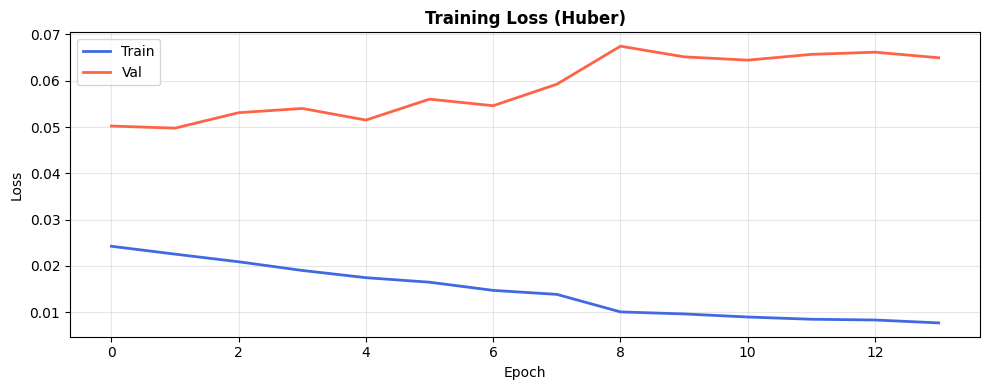

In [31]:
# Plot training curves
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history['train_loss'], label='Train', color='royalblue', linewidth=2)
ax.plot(history['val_loss'],   label='Val',   color='tomato',    linewidth=2)
ax.set_title('Training Loss (Huber)', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lstm_training_curves.png', dpi=150)
plt.show()

## 🧪 Step 5: Evaluation

We use **MAE** (mean absolute error in MW) and **MAPE** (mean absolute percentage error) as primary metrics — these are intuitive for energy forecasting. We also compare against a simple **persistence baseline** (predict tomorrow = today).

In [32]:

# LOAD BEST MODEL & EVALUATE ON TEST SET
# We inverse-transform predictions back to MW
# for interpretable metrics


model.load_state_dict(torch.load('best_lstm_model.pt', map_location=DEVICE))
_, test_preds_scaled, test_targets_scaled = eval_epoch(model, test_loader, criterion, DEVICE)

# Inverse transform: we need a (N, n_features) array to invert the scaler
# We only care about the MW column (index 0)
def inverse_mw(scaled_values, scaler, target_idx=0):
    """Inverse transform only the MW (target) dimension."""
    # Create dummy array with the right number of features
    n_samples, horizon = scaled_values.shape
    dummy = np.zeros((n_samples * horizon, scaler.n_features_in_))
    dummy[:, target_idx] = scaled_values.flatten()
    inverted = scaler.inverse_transform(dummy)[:, target_idx]
    return inverted.reshape(n_samples, horizon)

test_preds_mw   = inverse_mw(test_preds_scaled,   scaler)
test_targets_mw = inverse_mw(test_targets_scaled, scaler)

# Flatten for overall metrics
preds_flat   = test_preds_mw.flatten()
targets_flat = test_targets_mw.flatten()

mae  = mean_absolute_error(targets_flat, preds_flat)
rmse = np.sqrt(mean_squared_error(targets_flat, preds_flat))
mape = np.mean(np.abs((targets_flat - preds_flat) / targets_flat)) * 100

# Persistence baseline: predict next 24h = same as last 24h
# We compute this on test_targets (shifting by 24 hours)
persist_preds   = test_targets_mw[:, :24]  # use current period as proxy
# Simplified persistence — shift targets forward to simulate "yesterday as forecast"
persist_mae  = mean_absolute_error(targets_flat[:len(targets_flat)//2], targets_flat[len(targets_flat)//2:])


print(f'LSTM  — MAE: {mae:.1f} MW | RMSE: {rmse:.1f} MW | MAPE: {mape:.2f}%')
print(f'Baseline (persistence) — MAE: ~{persist_mae:.0f} MW (rough estimate)')
print('=' * 50)

TEST SET METRICS
LSTM  — MAE: 591.4 MW | RMSE: 817.0 MW | MAPE: 4.00%
Baseline (persistence) — MAE: ~1917 MW (rough estimate)


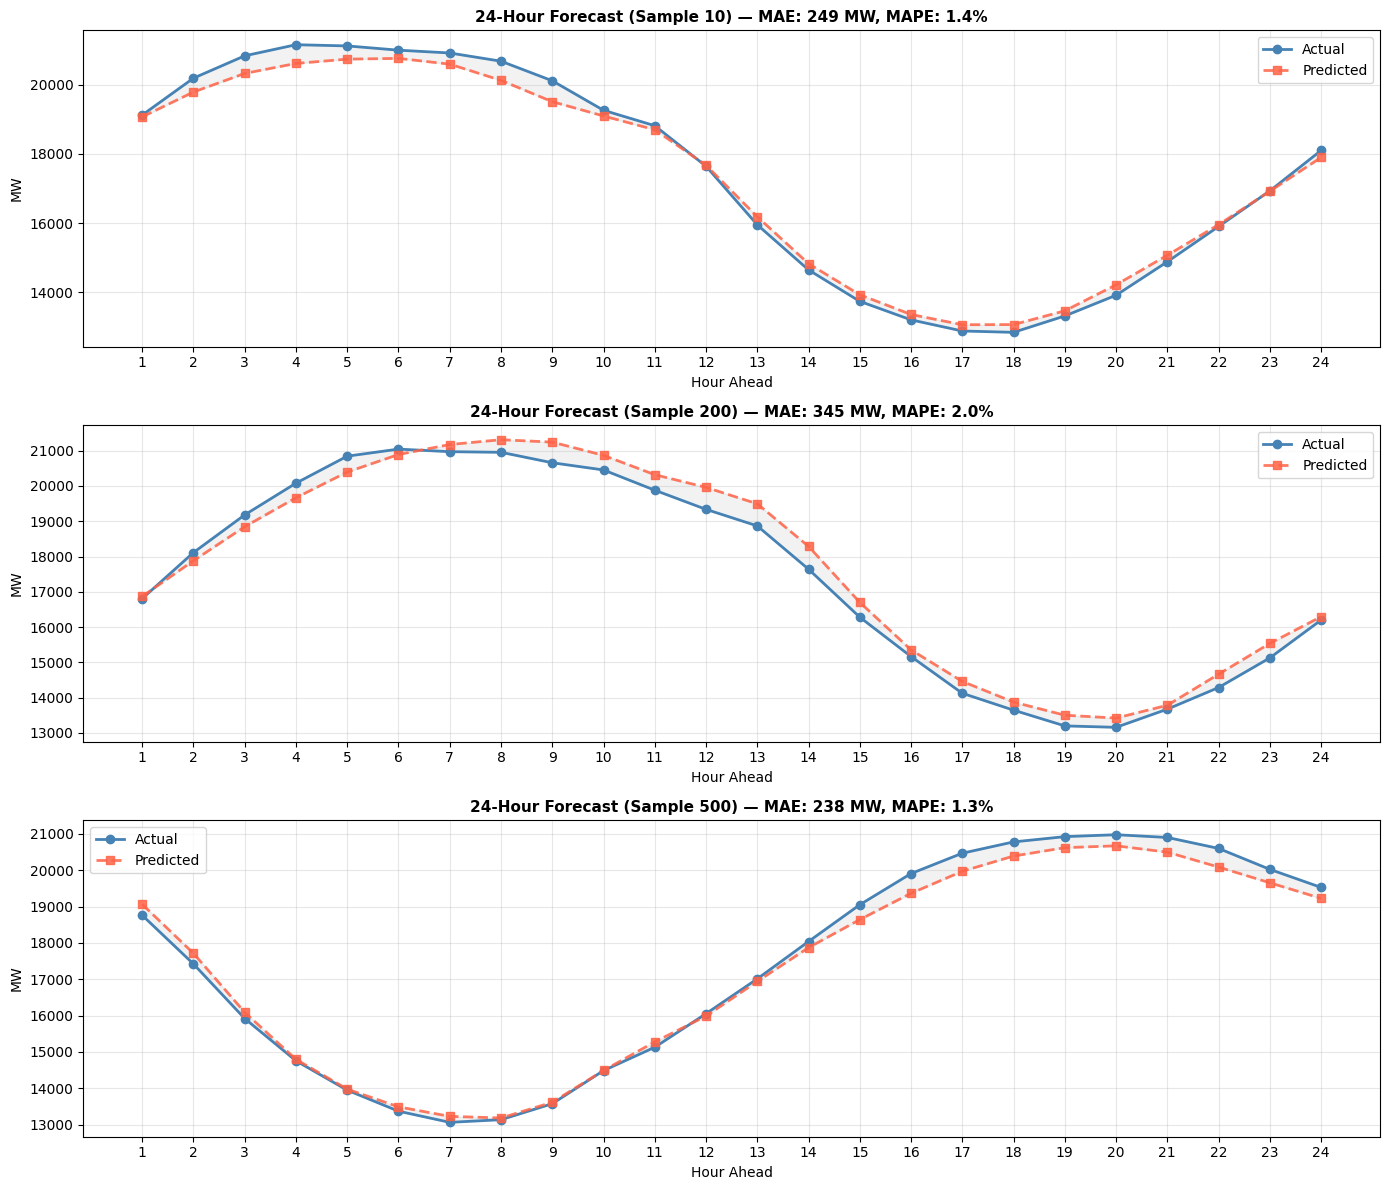

In [33]:

# FORECAST VISUALIZATION
# We plot several 24-hour prediction windows
# to get an intuition for model behavior


fig, axes = plt.subplots(3, 1, figsize=(14, 12))

sample_indices = [10, 200, 500]  # pick a few test windows to plot
hours = np.arange(1, HORIZON + 1)

for ax, idx in zip(axes, sample_indices):
    if idx < len(test_preds_mw):
        actual = test_targets_mw[idx]
        pred   = test_preds_mw[idx]

        ax.plot(hours, actual, 'o-', color='steelblue', label='Actual',    linewidth=2)
        ax.plot(hours, pred,   's--', color='tomato',  label='Predicted',  linewidth=2, alpha=0.85)
        ax.fill_between(hours, actual, pred, alpha=0.1, color='gray')

        sample_mae  = mean_absolute_error(actual, pred)
        sample_mape = np.mean(np.abs((actual - pred) / actual)) * 100

        ax.set_title(f'24-Hour Forecast (Sample {idx}) — MAE: {sample_mae:.0f} MW, MAPE: {sample_mape:.1f}%',
                     fontsize=11, fontweight='bold')
        ax.set_xlabel('Hour Ahead')
        ax.set_ylabel('MW')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_xticks(range(1, HORIZON + 1))

plt.tight_layout()
plt.savefig('forecast_examples.png', dpi=150)
plt.show()

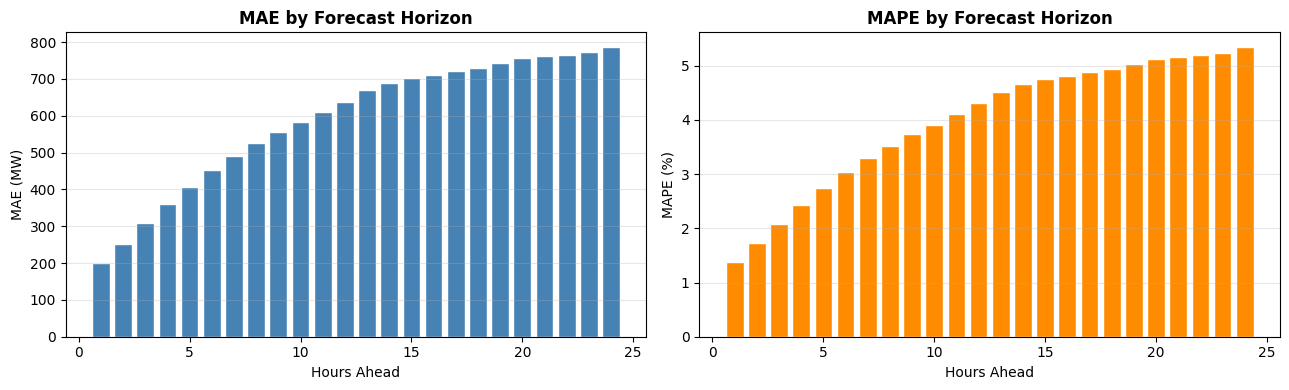

Hour 1  MAE: 199.2 MW
Hour 12 MAE: 638.6 MW
Hour 24 MAE: 787.2 MW


In [34]:

# ERROR BY FORECAST HORIZON
# Does accuracy degrade as we forecast further?
# This tells you where the model struggles.


mae_by_hour  = [mean_absolute_error(test_targets_mw[:, h], test_preds_mw[:, h]) for h in range(HORIZON)]
mape_by_hour = [np.mean(np.abs((test_targets_mw[:, h] - test_preds_mw[:, h]) / test_targets_mw[:, h])) * 100
                for h in range(HORIZON)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(range(1, HORIZON + 1), mae_by_hour, color='steelblue', edgecolor='white')
axes[0].set_title('MAE by Forecast Horizon', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Hours Ahead')
axes[0].set_ylabel('MAE (MW)')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(range(1, HORIZON + 1), mape_by_hour, color='darkorange', edgecolor='white')
axes[1].set_title('MAPE by Forecast Horizon', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Hours Ahead')
axes[1].set_ylabel('MAPE (%)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('error_by_horizon.png', dpi=150)
plt.show()

print(f'Hour 1  MAE: {mae_by_hour[0]:.1f} MW')
print(f'Hour 12 MAE: {mae_by_hour[11]:.1f} MW')
print(f'Hour 24 MAE: {mae_by_hour[23]:.1f} MW')

## 🔮 Improvements & Future Work

| Idea | Expected Benefit |
|------|------------------|
| **LSTM with Attention** | Model can focus on relevant past windows (e.g., same time yesterday) |
| **Temporal Fusion Transformer (TFT)** | State-of-the-art on many time series benchmarks |
| **N-BEATS / N-HiTS** | Purpose-built neural forecasting architectures |
| **Weather features** | Temperature and humidity correlate strongly with energy demand |
| **Probabilistic forecasting** | Predict confidence intervals, not just point estimates |
| **Multi-region joint model** | Use all PJM regions together for better data utilization |
| **Quantile regression loss** | Predict P10/P50/P90 quantiles for risk-aware grid planning |